"Reworked" test_vdisp - further explored the relation beween theta_E,theta_E(v_disp) and core, since the simple kappa_max parametrisation did not work


In [7]:
import dill
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpl_toolkits.axes_grid1 import make_axes_locatable

from python_tools.get_res import load_whatever

from nazgul.test_vdisp import get_kw_tE
from nazgul.stat_lenses import get_all_gallens

In [2]:
from importlib import reload
from nazgul import stat_lenses
reload(stat_lenses)
from stat_lenses import get_all_gallens


In [3]:
theta_sis_list = kw_tE["theta_E_sis"]
K_c = np.array([l.kappa_map.max() for l in lenses])
theta_E_list   = kw_tE["theta_E"]
plt.scatter(K_c,theta_E_list/theta_sis_list,c="g")
x_kc = np.linspace(1,9,100)
y_kc = np.sqrt(1-1/x_kc)
plt.plot(x_kc,y_kc,ls="--",c="k",label=r"f($\kappa_{\rm{max}}$) = $\sqrt{1-\frac{1}{\kappa_{\rm{max}}}}$")
plt.xlabel(r"$\kappa_{\rm{max}}$")
plt.ylabel(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$")
plt.title(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$ wrt $\kappa_{\rm{max}}$ and fit for $\kappa_{\rm{c}}=\kappa_{\rm{max}}$")
plt.legend()
plt.xlim(0,20)
plt.show()

NameError: name 'kw_tE' is not defined

In [4]:
plt.scatter(K_c,theta_E_list,marker="x",c="b")
plt.xlim(0,50)
plt.ylabel(r"$\theta_{\rm{E}}$")
plt.xlabel(r"$\kappa_{\rm{max}}$")
plt.show()
plt.scatter(K_c,theta_sis_list,marker="x",c="b")
plt.xlim(0,50)
plt.ylabel(r"$\theta_{\rm{E}}(\sigma_{\rm{v}})$")
plt.xlabel(r"$\kappa_{\rm{max}}$")
plt.show()

NameError: name 'K_c' is not defined

def comp_tE_vs_tEsis(reload=True,
                     out_dll = "tmp/theta_sis.dll",
                     name_plot = "tmp/tE_sis_vs_comp.png",
                     title = r"Compare $\theta_E$",
                    kw_get_gallens={},
                    kwargs_query={},
                    correct_core=True,
                    compute_q=True):
    
    if reload:
        try:
            kw_tE = load_whatever(out_dll)
            print(f"Loaded prev. res. {out_dll}")
        except:
            print(f"Failed to load {out_dll}")
            reload = False
    if reload == False:
        lenses  = get_all_gallens(verbose=False,**kw_get_gallens)
        kw_tE = get_kw_tE(lenses=lenses,
                         out_dll=out_dll,
                          kwargs_query=kwargs_query,
                          correct_core=correct_core,
                          compute_q=compute_q)
    theta_sis_list = kw_tE["theta_E_sis"]
    theta_E_list   = kw_tE["theta_E"]
    zs             = kw_tE["z_lens"]
    if correct_core:
        R_cc = kw_tE["Ratio_Core_Corr"]
    if compute_q:
        q = kw_tE["q"]
    fig,axis = plt.subplots(1,2, figsize=(8, 4))
    plt.suptitle(title)
    ax = axis[0]
    sis_range = theta_sis_list.min(),theta_sis_list.max()
    sis_11 = np.linspace(*sis_range,10)
    tE_11 = np.linspace(*sis_range,10)
    ax.plot(sis_11,tE_11,ls="--",c="k",label="1:1")
    im0 = ax.scatter(theta_sis_list,theta_E_list,marker=".",c=zs,cmap="viridis")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    if correct_core:
        ax.scatter(theta_sis_list*R_cc,theta_E_list,marker="x",c=zs,
                   cmap="viridis",label=r"$\theta_c$ correction")
    fig.colorbar(im0, cax=cax, orientation='vertical',label=r"z$_{lens}$")
    ax.axis('equal')
    ax.set_ylabel(r"$\theta_E$")
    ax.set_xlabel(r"$\theta_E(\sigma_{\rm{v}})$")
    ax.legend()
    
    ax = axis[1]
    x = np.arange(len(theta_sis_list))
    im0 = ax.scatter(x,theta_E_list/theta_sis_list,marker=".",c=zs,cmap="viridis")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    if correct_core:
        ax.scatter(x,theta_E_list/(theta_sis_list*R_cc),marker="x",c=zs,
                   cmap="viridis",label=r"$\theta_c$ correction")

    fig.colorbar(im0, cax=cax, orientation='vertical',label=r"z$_{lens}$")
    ax.plot(x,np.ones_like(x),ls="--",c="k",label="1")
    
    ax.set_xlabel(r"Gal")
    ax.set_ylabel(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$")
    ax.legend()
    plt.tight_layout()
    plt.savefig(name_plot)
    #plt.show()
    print(f"Saving {name_plot}")
    plt.close("all")
    if correct_core:
        tE_ratio = theta_E_list/(theta_sis_list)
        tE_ratio_corr = tE_ratio/R_cc
        nbins =10
        print("N=",len(tE_ratio))


        plt.hist(tE_ratio,bins=nbins,alpha=.5,color="b",label=r"Original N="+str(len(tE_ratio)))
        plt.axvline(np.nanmedian(tE_ratio),c="b",ls="--",label=r"$\theta_E/\theta_{\rm{E, SIS}}(\sigma_{\rm{v}})$="+str(np.round(np.nanmedian(tE_ratio),1)))
        plt.hist(tE_ratio_corr,bins=nbins,color="r",alpha=.5,label=r"$\theta_c$ correction")
        plt.axvline(np.nanmedian(tE_ratio_corr),c="r",ls="--",label=r"$\theta_E/(\theta_{\rm{E, SIS}}(\sigma_{\rm{v}}*\rm{R}_{\rm{cc}})$="+str(np.round(np.nanmedian(tE_ratio_corr),1)))
        plt.title(r"$\theta_E$ ratio from mass map and from $\sigma_v$ with/wo cored profile correction")
        plt.yticks([])
        plt.legend()
        plt.xlabel(r"$\theta_E/\theta_{\rm{E, SIS}}(\sigma_{\rm{v}})$")
        plt.tight_layout()
        name_plot2 = name_plot.replace(".png","_2.png")
        name_plot2 = name_plot2.replace(".pdf","_2.pdf")
        plt.savefig(name_plot2)
        print(f"Saving {name_plot2}")
        plt.close("all")
        
        #K_c = 1/(1 -R_cc**2)
        # TEST!
        lenses  = get_all_gallens(verbose=False,**kw_get_gallens)
        K_c = [l.kappa_map.max() for l in lenses]
        plt.scatter(K_c,theta_E_list/theta_sis_list,c="g")
        x_kc = np.linspace(1,9,100)
        y_kc = np.sqrt(1-1/x_kc)
        plt.plot(x_kc,y_kc,ls="--",c="k",label=r"f($\kappa_{\rm{max}}$) = $\sqrt{1-\frac{1}{\kappa_{\rm{max}}}}$")
        plt.xlabel(r"$\kappa_{\rm{max}}$")
        plt.ylabel(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$")
        plt.title(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$ wrt $\kappa_{\rm{max}}$ and fit for $\kappa_{\rm{c}}=\kappa_{\rm{max}}$")
        plt.legend()
        name_plot3 = name_plot2.replace("_2.","_kc_vs_tEratio_1.")
        plt.savefig(name_plot3)
        print(f"Saving {name_plot3}")
        plt.close("all")
        
        print("Ugly but fast: output lenses for which the correction is not sufficient and plot their kappa map")
        if not reload:
            lenses  = get_all_gallens(verbose=False,**kw_get_gallens)
        #np.where(tE_ratio_corr<thresh_tE_ratio_corr,
        if compute_q:
            fig,ax = plt.subplots(1) 
            x = np.arange(len(theta_sis_list))
            im0 = ax.scatter(x,theta_E_list/theta_sis_list,marker=".",c=q,cmap="viridis")
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            if correct_core:
                ax.scatter(x,theta_E_list/(theta_sis_list*R_cc),marker="x",c=q,
                           cmap="viridis",label=r"$\theta_c$ correction")
        
                fig.colorbar(im0, cax=cax, orientation='vertical',label=r"q$_{lens}$")
            ax.plot(x,np.ones_like(x),ls="--",c="k",label="1")
            
            ax.set_xlabel(r"Gal")
            ax.set_ylabel(r"$\theta_E$/$\theta_E(\sigma_{\rm{v}})$")
            ax.legend()
            plt.tight_layout()
            name_plot4 = name_plot2.replace("_2.","_q.")
            #plt.show()
            plt.savefig(name_plot4)
            print(f"Saving {name_plot4}")
            plt.close("all")
    

In [5]:
from nazgul.stat_gamma_1Ddens import std_kw_get_all_gallens
from nazgul.stat_lenses import get_catdir_stat
from nazgul.test_vdisp import comp_tE_vs_tEsis
"""std_kw_get_all_gallens = {"sim":std_sim,
                          "subsim":std_subsim,
                          "simsuite":std_simsuite,
                          "snaps":[]}"""

snaps = ["0110"]
kw_get_gallens = std_kw_get_all_gallens
kw_get_gallens["snaps"] = snaps
#sim=std_sim
#simsuite = std_simsuite
#subsim = std_subsim
correct_core = True
compute_q = True
reload = False
# COLIBRE version
#kw_get_gallens = {"snaps":snaps,
#                     "sim":sim,
#                     "subsim":subsim,
#                     "simsuite":simsuite,} 
cat_dir = get_catdir_stat(**kw_get_gallens)
name_plot = f"{cat_dir}/tE_sis_vs_comp.png"
out_dll = f"{cat_dir}/theta_sis.dll"
title = r"Compare $\theta_E$"

kwargs_query= {}
comp_tE_vs_tEsis(reload=reload,
                     title=title,
                    kw_get_gallens=kw_get_gallens,
                    kwargs_query=kwargs_query,
                    out_dll = out_dll,
                    name_plot=name_plot,
                    correct_core=correct_core,
                    compute_q=compute_q
                    )


Running get_all_gallens silently...
tE= 0.56 arcsec
tE_sis= 0.74 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.76
Ratio of theta_E computed vs theta_E_sis from vel. disp  (core corr.): 0.78
tE= 0.62 arcsec
tE_sis= 0.9 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.7
Ratio of theta_E computed vs theta_E_sis from vel. disp  (core corr.): 0.72
tE= 0.5 arcsec
tE_sis= 0.8 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.62
Ratio of theta_E computed vs theta_E_sis from vel. disp  (core corr.): 0.63
tE= 0.5 arcsec
tE_sis= 0.79 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.63
Ratio of theta_E computed vs theta_E_sis from vel. disp  (core corr.): 0.69
tE= 0.72 arcsec
tE_sis= 0.89 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.81
Ratio of theta_E computed vs theta_E_sis from vel. disp  (core corr.): 0.91
tE= 0.74 arcsec
tE_sis= 1.02 arcsec
Ratio of theta_E computed vs theta_E_sis from vel. disp: 0.73
R

![title](RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/CatGal_snap_0110/tE_sis_vs_comp_2.png)

In [24]:
lenses  = get_all_gallens(verbose=False,**kw_get_gallens)

Running get_all_gallens silently...


[]

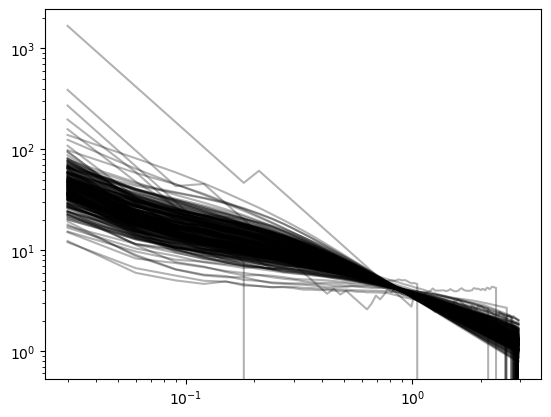

In [65]:
for lens in lenses:
    kappa = lens.kappa_map
    imax = np.where(kappa==kappa.max())
    imax_y = imax[0][0]
    imax_x = imax[1][0]
    rng =0
    kk_int = []
    rngs =  np.arange(0,int(kappa.shape[0]/2)-1)
    for rng in rngs:
        k_crop = kappa[imax_y-rng:imax_y+rng+1,imax_x-rng:imax_x+rng+1]
        kk_int.append(np.sum(k_crop)/rng**2)
    RE_pix = lens.thetaE.value*lens.pixel_num/(2*lens.radius.value)
    plt.plot(rngs/RE_pix,kk_int,c="k",alpha=.3)

plt.loglog()

In [ ]:
def get_k_max(kappa,rng=1):
    kappa = np.asarray(kappa)
    imax = np.where(kappa==kappa.max())
    

![title](RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/CatGal_snap_0110/tE_sis_vs_comp.png)
![title](RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/CatGal_snap_0110/tE_sis_vs_comp_2.png)
![title](RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/CatGal_snap_0110/tE_sis_vs_comp_kc_vs_tEratio_1.png)
![title](RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/CatGal_snap_0110/tE_sis_vs_comp_q.png)

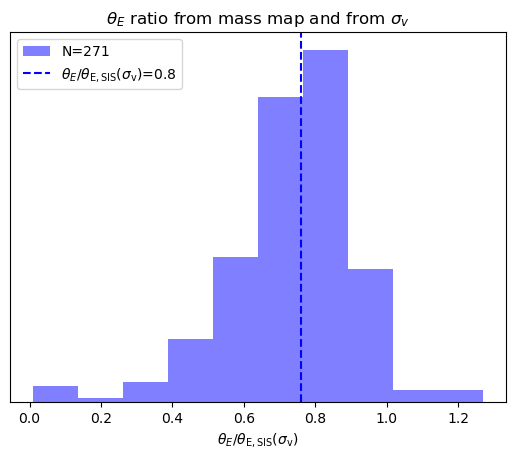

In [9]:
kw_tE = load_whatever(out_dll)
theta_sis_list = kw_tE["theta_E_sis"]
theta_E_list   = kw_tE["theta_E"]
zs             = kw_tE["z_lens"]
tE_ratio = theta_E_list/(theta_sis_list)
nbins =10
plt.hist(tE_ratio,bins=nbins,alpha=.5,color="b",label=r"N="+str(len(tE_ratio)))
plt.axvline(np.nanmedian(tE_ratio),c="b",ls="--",label=r"$\theta_E/\theta_{\rm{E, SIS}}(\sigma_{\rm{v}}$)="+str(np.round(np.nanmedian(tE_ratio),1)))
plt.yticks([])
plt.xlabel(r"$\theta_E/\theta_{\rm{E, SIS}}(\sigma_{\rm{v}})$")
plt.title(r"$\theta_E$ ratio from mass map and from $\sigma_v$")

plt.legend()
plt.show()

Text(0, 0.5, '$\\theta_E/\\theta_{E,SIS}$')

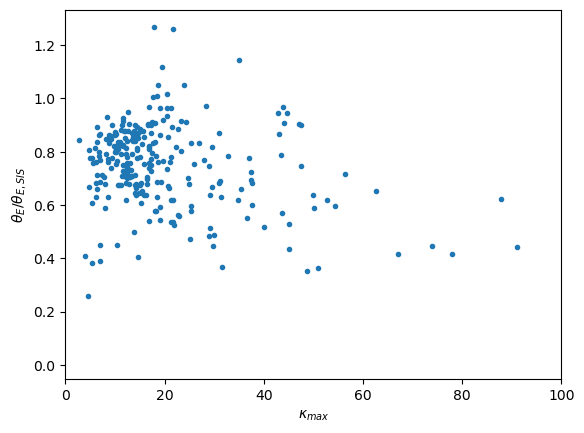

In [15]:
rcc = kw_tE["Ratio_Core_Corr"]
#rcc =  np.sqrt(1-(1/kmax.value))
kmax = 1/(1- rcc**2)

plt.scatter(kmax,theta_E_list/theta_sis_list,marker=".")
plt.xlim(0,100)
plt.xlabel(r"$\kappa_{max}$")
plt.xlabel(r"$\kappa_{max}$")
plt.ylabel(r"$\theta_E/\theta_{E,SIS}$")


Text(0, 0.5, '$\\theta_E/\\theta_{E,SIS,corrected}$')

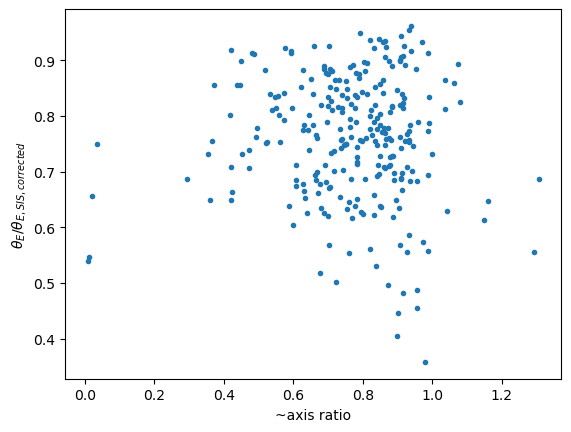

In [22]:
theta_sis_list = kw_tE["theta_E_sis"]
theta_E_list   = kw_tE["theta_E"]
q_list          =  kw_tE["q"]
plt.scatter(theta_E_list/(theta_sis_list*rcc),q_list,marker=".")
plt.xlabel("~axis ratio")
plt.ylabel(r"$\theta_E/\theta_{E,SIS,corrected}$")


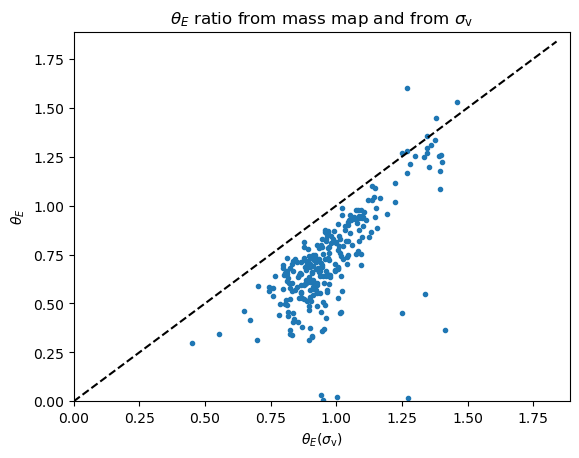

In [68]:
fig,ax = plt.subplots()
ax.scatter(theta_sis_list,theta_E_list,marker=".")
ax.set_title(r"$\theta_E$ ratio from mass map and from $\sigma_{\rm{v}}$")
ax.set_xlabel(r"$\theta_E/\theta_{E,SIS}$")


ax.set_ylabel(r"$\theta_E$")
ax.set_xlabel(r"$\theta_E(\sigma_{\rm{v}})$")
sis_range = theta_sis_list.min(),theta_sis_list.max()
tE_range  = theta_E_list.min(),theta_E_list.max()
sis_11 = np.linspace(0,sis_range[1],10)
tE_11 = np.linspace(0,sis_range[1],10)
ax.plot(sis_11,tE_11,ls="--",c="k",label="1:1")

#ax.axis('equal')
ax.set_xlim(0,np.max(sis_11)+0.05)
ax.set_ylim(0,np.max(sis_11)+0.05)
plt.savefig("tmp/tE_vs_tEvdisp.pdf")


In [214]:
from nazgul import stat_gamma_1Ddens
from importlib import reload
import nazgul
reload(nazgul.stat_gamma_1Ddens)
from stat_gamma_1Ddens import get_core_gamma_1gal

In [215]:
get_core_gamma_1gal

<function stat_gamma_1Ddens.get_core_gamma_1gal(gal_lens, res_dir, single_plot=True)>

In [88]:
from nazgul.combined_modelling_results import get_res_dir
from nazgul.stat_gamma_1Ddens import get_core_gamma

lens_model = "simNoShear"
res_dir            = get_res_dir(lens_model)
# copied by hand wrt stat_gamma_1Dlens
lenses2skip = ["LS_Lens_Gn75SGn0_Prj1","LS_Lens_Gn4SGn0_Prj2","LS_Lens_Gn4SGn0_Prj0","LS_Lens_Gn14SGn0_Prj1",
               "LS_Lens_Gn71SGn0_Prj2","LS_Lens_Gn7SGn1_Prj2","LS_Lens_Gn15SGn1_Prj0","LS_Lens_Gn15SGn1_Prj0",
               "LS_Lens_Gn6SGn0_Prj2","LS_Lens_Gn1SGn2_Prj1","LS_Lens_Gn42SGn0_Prj1","LS_Lens_Gn18SGn0_Prj2",
               "LS_Lens_Gn18SGn0_Prj0","LS_Lens_Gn18SGn0_Prj0","LS_Lens_Gn18SGn0_Prj2","LS_Lens_Gn22SGn1_Prj2",
               "LS_Lens_Gn22SGn1_Prj1","LS_Lens_Gn66SGn0_Prj1","LS_Lens_Gn45SGn0_Prj0","LS_Lens_Gn33SGn0_Prj2"]
kw_core = get_core_gamma(reload=True,
                    res_dir=res_dir,  
                    min_thetaE=None,
                    single_plot=True,
                    lenses2skip=lenses2skip,
                    kw_get_all_gallens=std_kw_get_all_gallens)

Tried and failed to load previous result. Recomputing
Loading previously computed catalogue of lenses to models /cosma/home/do019/dc-quei1/nazgul/src/nazgul/results/models/simNoShear/CLB_L0050N0752_THERMAL_AGN_m6/cat_lens2model.dll
Catalogue /cosma/home/do019/dc-quei1/nazgul/src/nazgul/results/models/simNoShear/CLB_L0050N0752_THERMAL_AGN_m6/cat_lens2model.dll exists, but doen't have the same requirements. Ignored and updated
Unpacking basic lens...
File (base)/RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/snap_0110/Gn1006030/Gal/G1006030.dll is present
Loaded (base)/RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/snap_0110/Gn1006030/Gal/G1006030.dll:
Gal G1006030, at z=0.2/snap=0110, with 
N=1.3E+06 part.
of 
tot Mass=3.2E+12 [M_sun]

File (base)/RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/snap_0110/Gn1006030/Sub/Sub_Lens_G1006030_Prj0_OlS4B0.pkl is present
Loaded (base)/RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/snap_0110/Gn1006030/Sub/Sub_Lens_G1006030_Prj0_OlS4B0.pkl:
Sub_Lens_G10060

In [95]:
lenses  = get_all_gallens(verbose=False,**kw_get_gallens)

Getting gallenses silently...


In [278]:
from nazgul.plot_AMRxpart import get_kw_1D_density,get_savedir_plots
from scipy.optimize import curve_fit
from nazgul.Modelling.lib_models import get_lenses2model,get_model_res_dir
from nazgul.combined_modelling_results import get_full_chain,get_res_dir,get_model_from_res_dir

from nazgul.mount_doom.lens_system import LensSystem

import warnings
from python_tools.tools import silencer

@silencer
def get_core_1gal(gal_lens,res_dir,single_plot=True,smooth=False,verbose=True):
    print("\nLoading gal lens "+gal_lens.name)
    gal_lens.unpack()
    kw_1d = get_kw_1D_density(gal_lens.Gal,gal_lens.proj_index)
            
    r = kw_1d["r_all"].value #kpc
    Sigma = kw_1d["Sigma_encl_all"].value
    Sigma_scaled = Sigma/1e9 # 1e9 SolMass/kpc
    if not smooth:
        fit_prm,fit_cov = curve_fit(rho_cored,r,Sigma_scaled)
    else:
        print("Fitting for smoothed power law")
        fit_prm,fit_cov = curve_fit(rho_cored_smooth,r,Sigma_scaled)
    
    rho0    = fit_prm[0]
    core    = fit_prm[1]
    return core


In [279]:
cores_smooth = []
for gal_lens in lenses:
    try:
        res = get_core_1gal(gal_lens,res_dir,smooth=True,single_plot=False,verbose=False)
    except RuntimeError:
        res = -100
    cores_smooth.append(res)
cores_smooth = np.array(cores_smooth)

Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...
Running get_core_1gal silently...


In [305]:
cores_smooth[cores_smooth>60].shape

(22,)

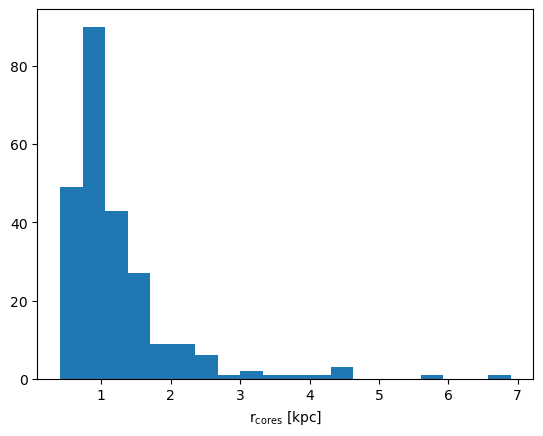

In [283]:
i_cores = (cores_smooth>0) & (cores_smooth<60)
plt.hist(cores_smooth[i_cores],bins=20)
plt.xlabel(r"r$_{\rm{cores}}$ [kpc]")
plt.show()

### Parenthesis - why are there negative cores?
note: this was true when fitting the core with
$$ \rho = \rho_0 / (r^2 + r_{core}^2)$$
when computing the smooth core, we do not get negative cores, but we do get 5 cases where the fit fails and several (22) cases where the core is larger than 60kpc!

In [123]:
lenses_neg_cores = np.array(lenses)[cores<0]
neg_cores = cores<0


Loading gal lens Sub_Lens_G1006045_Prj2
Reloaded /cosma/home/do019/dc-quei1/nazgul/src/nazgul/RingBearer/COLIBRE/L0050N0752/THERMAL_AGN_m6/snap_0110/Gn1006045/Projection/kw_1D_dens_2.dll
Results from 1D density Cored Power Law fit
Core : -1.72
Gamma : 0.69


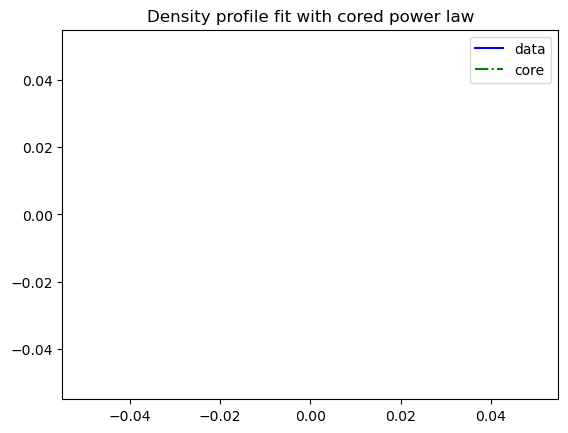

In [124]:
# test one
lnc = lenses_neg_cores[0]
gamma,core,gamma_lens,log_r_scaled,log_Sig_scaled = get_core_gamma_1gal(lnc,res_dir,False)

fig,ax = plt.subplots()
ax.set_title("Density profile fit with cored power law")
ax.plot(log_r_scaled,log_Sig_scaled,c="b",label="data")
#ax.plot(log_r,np.log10(rho_cored(r,*fit_prm)),c="g",
#     ls="--",label="fit cored PL")
#ax.set_xlabel(r_lbl)
#ax.set_ylabel(sig_lbl)
ax.axvline(np.log10(core),ls="-.",c="g",label="core")
ax.legend()



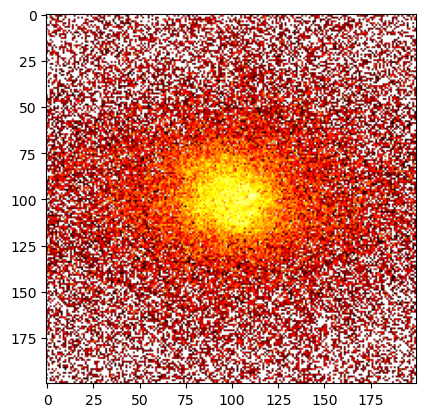

In [107]:
plt.imshow(np.log10(lnc.kappa_map),cmap="hot")

In [125]:
def get_kwisokappa(lens):
    pth = [i for i in lens.pkl_path.parent.glob(f"kw_res_isodens_prj{lens.proj_index}*")]
    assert len(pth)==1
    return load_whatever(pth[0])
get_kwisokappa(lnc)

AssertionError: 

In [160]:
lenses_neg_core_fitisokappa = []
neg_core_fitisokappa = []
for lens in lenses_neg_cores:
    try:
        kw_isokappa = get_kwisokappa(lens)
        lenses_neg_core_fitisokappa.append(lens)
        neg_core_fitisokappa.append(kw_isokappa)
        
        print(f"<<<<   Lens {lens} has kappa isodens contours   >>>")
    except AssertionError:
        print(f"lens {lens} has NO kappa isodens contours")
#soap_index,prj = get_gn_prj(gln)
#lens = get_lens(soap_index,snap,prj)


lens Sub_Lens_G1006045_Prj2 has no kappa isodens contours
lens Sub_Lens_G1079926_Prj1 has no kappa isodens contours
<<<<lens Sub_Lens_G1109962_Prj2 has kappa isodens contours>>>
<<<<lens Sub_Lens_G1251287_Prj0 has kappa isodens contours>>>
<<<<lens Sub_Lens_G1251287_Prj2 has kappa isodens contours>>>
<<<<lens Sub_Lens_G1301711_Prj0 has kappa isodens contours>>>
<<<<lens Sub_Lens_G21162_Prj1 has kappa isodens contours>>>
lens Sub_Lens_G21162_Prj2 has no kappa isodens contours
lens Sub_Lens_G246434_Prj1 has no kappa isodens contours
<<<<lens Sub_Lens_G272486_Prj0 has kappa isodens contours>>>
<<<<lens Sub_Lens_G295176_Prj1 has kappa isodens contours>>>
<<<<lens Sub_Lens_G311546_Prj0 has kappa isodens contours>>>
lens Sub_Lens_G545021_Prj1 has no kappa isodens contours
<<<<lens Sub_Lens_G598372_Prj1 has kappa isodens contours>>>
<<<<lens Sub_Lens_G657571_Prj2 has kappa isodens contours>>>
<<<<lens Sub_Lens_G657787_Prj2 has kappa isodens contours>>>
lens Sub_Lens_G688388_Prj0 has no kappa 

In [161]:
kw_isokappa.keys()

dict_keys(['isofit', 'loglogfit', 'cutoff_rad'])

[]

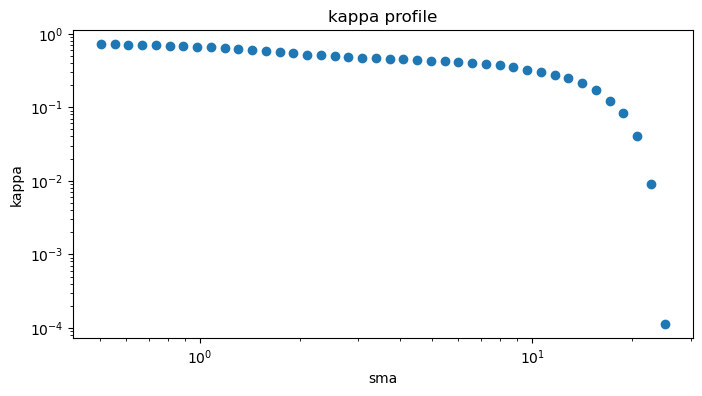

In [163]:
isolist = kw_isokappa["isofit"]["isolist"]


plt.figure(figsize=(8, 4))

plt.scatter(isolist.sma[1:], isolist.intens[1:])
plt.title("kappa profile")
plt.xlabel('sma')
plt.ylabel('kappa')
plt.loglog()



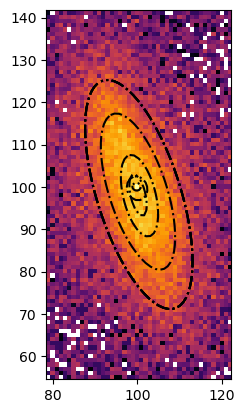

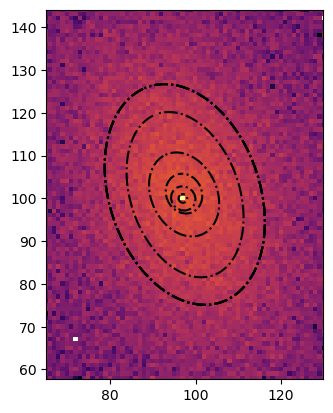

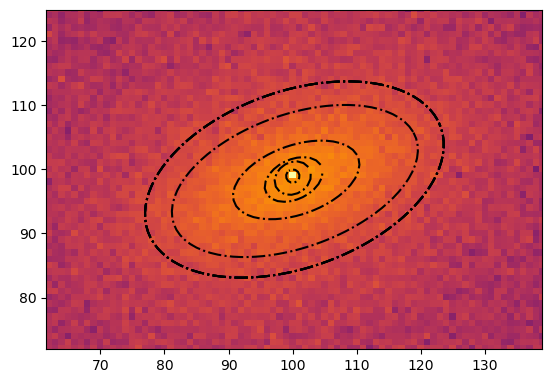

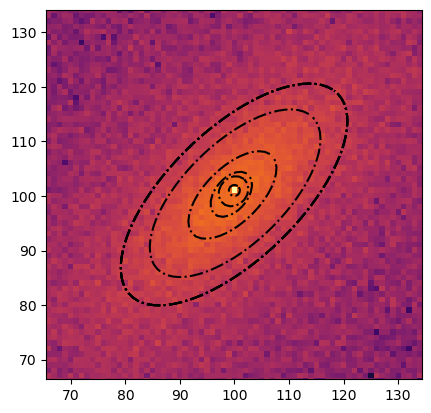

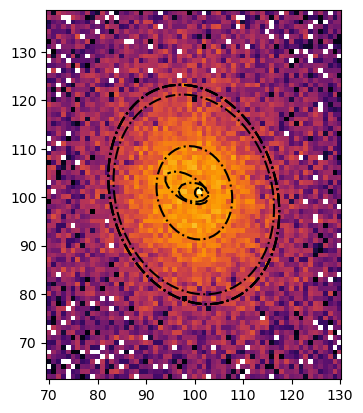

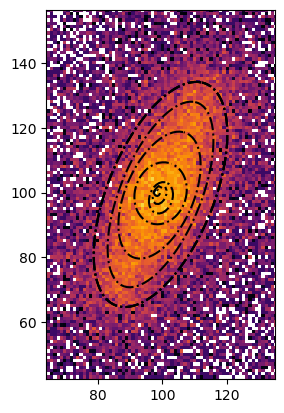

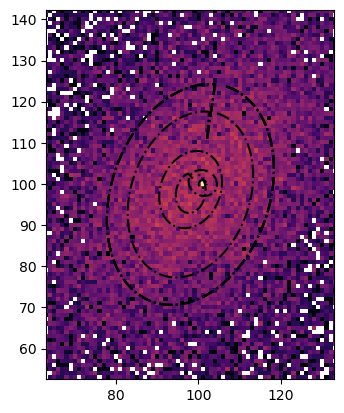

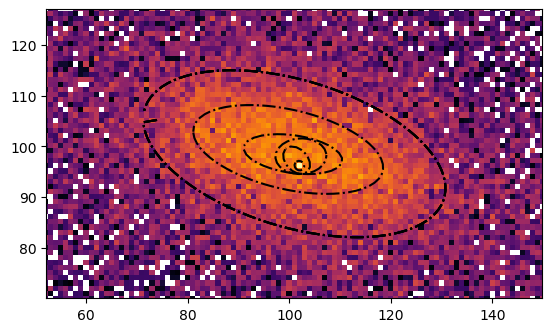

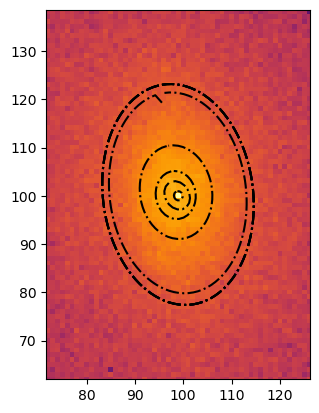

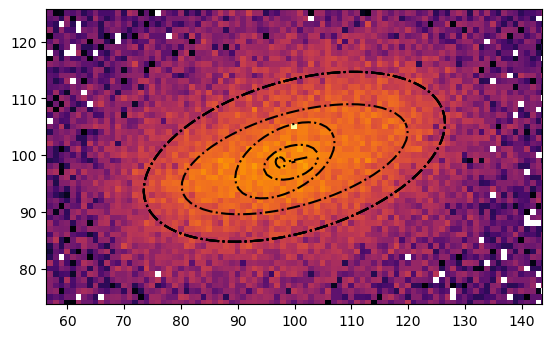

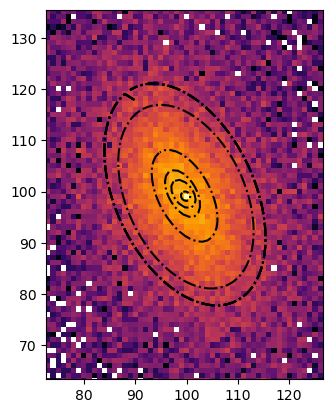

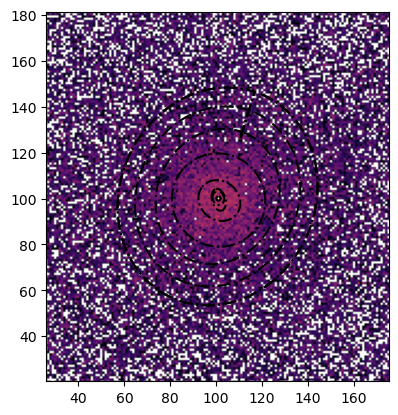

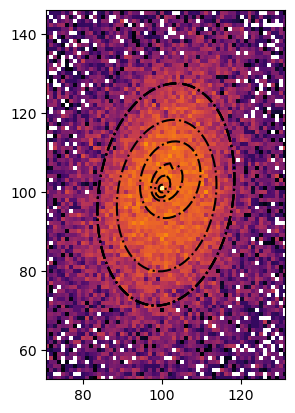

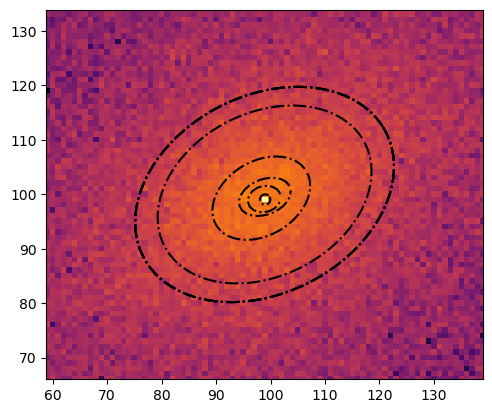

In [165]:
for i,lens in enumerate(lenses_neg_core_fitisokappa):
    isolist = neg_core_fitisokappa[i]["isofit"]["isolist"]
    plt.imshow(np.log10(lens.kappa_map),cmap="inferno")
    # overplot a few isophotes on the residual map
    for i in [1,3,5,10,20,30,40,50,100]:
        iso = isolist.get_closest(i)
        x, y, = iso.sampled_coordinates()
        plt.plot(x, y, color='k',ls="-.")
    plt.xlim(x.min()-x.std(),x.max()+x.std())
    plt.ylim(y.min()-y.std(),y.max()+y.std())
    plt.show()

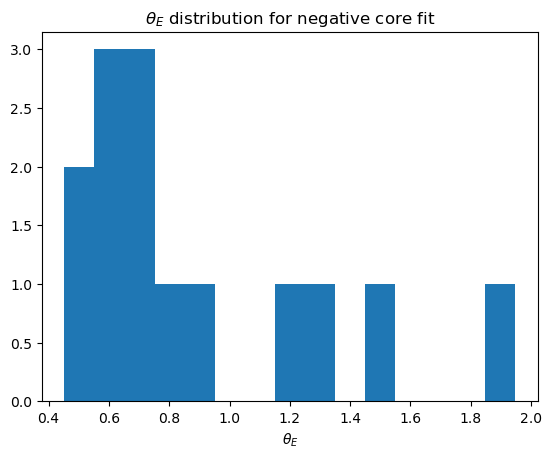

In [173]:
thetaE_neg_core_fitisokappa = np.array([l.thetaE.value for l in lenses_neg_core_fitisokappa])
plt.hist(thetaE_neg_core_fitisokappa,bins=15)
plt.title(r"$\theta_E$ distribution for negative core fit")
plt.xlabel(r"$\theta_E$")
plt.show()

Close the parenthesis on negative cores. \
Probably due to the very massive central pixel, either SMBH, very small core etc. Might be due to the resolution of the kappa map \
it does not seem to be only for small lenses however, as we have also large theta_E

## Restart comparison w core
Only consider positive ones for now

In [287]:
"""
tE_comp_core = np.array(tE)[i_cores]
tE_sis_comp_core = np.array(tE_sis)[i_cores]
tEsistE_ratio_comp_core = tE_comp_core/tE_sis_comp_core

for tE,tE_sis,core,lens in zip(theta_E_list,theta_sis_list,cores,lenses):
    tE_sis_ratio = tE/tE_sis
    if core>0 :
        tEsistE_ratio_comp_core.append(tE_sis_ratio)
        tE_sis_comp_core.append(tE_sis)
        tE_comp_core.append(tE)

fig,axis = plt.subplots(1,3,figsize=(15,5))
axis[0].scatter(cores[cores>0],tEsistE_ratio_comp_core,c="k",marker="x")
axis[0].set_xlabel("Core (>0)")
axis[0].set_ylabel(r"$\theta_E (\sigma_v)/\theta_E$")
axis[1].scatter(cores[cores>0],tE_sis_comp_core,c="k",marker="x")
axis[1].set_xlabel("Core (>0)")
axis[1].set_ylabel(r"$\theta_E (\sigma_v)$")
axis[2].scatter(cores[cores>0],tE_comp_core,c="k",marker="x")
axis[2].set_xlabel("Core (>0)")
axis[2].set_ylabel(r"$\theta_E$")
plt.show()"""

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

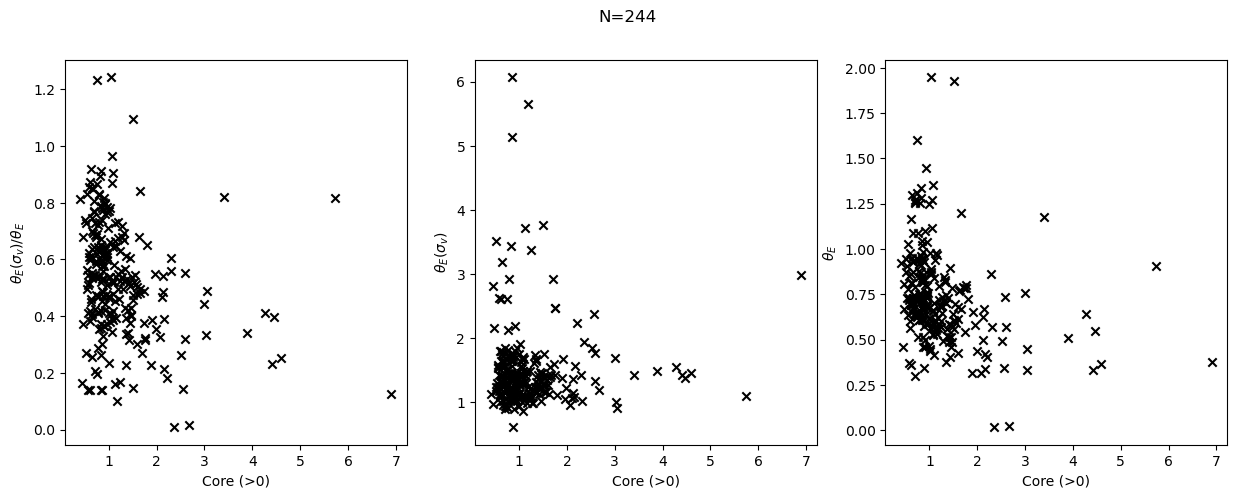

In [303]:
tE_comp_core = np.array(theta_E_list)[i_cores]
tE_sis_comp_core = np.array(theta_sis_list)[i_cores]
tEsistE_ratio_comp_core = tE_comp_core/tE_sis_comp_core


fig,axis = plt.subplots(1,3,figsize=(15,5))
axis[0].scatter(cores_smooth[i_cores],tEsistE_ratio_comp_core,c="k",marker="x")
axis[0].set_xlabel("Core (>0)")
axis[0].set_ylabel(r"$\theta_E (\sigma_v)/\theta_E$")
axis[1].scatter(cores_smooth[i_cores],tE_sis_comp_core,c="k",marker="x")
axis[1].set_xlabel("Core (>0)")
axis[1].set_ylabel(r"$\theta_E (\sigma_v)$")
axis[2].scatter(cores_smooth[i_cores],tE_comp_core,c="k",marker="x")
axis[2].set_xlabel("Core (>0)")
axis[2].set_ylabel(r"$\theta_E$")
plt.suptitle("N="+str(i_cores.sum()))
plt.show()

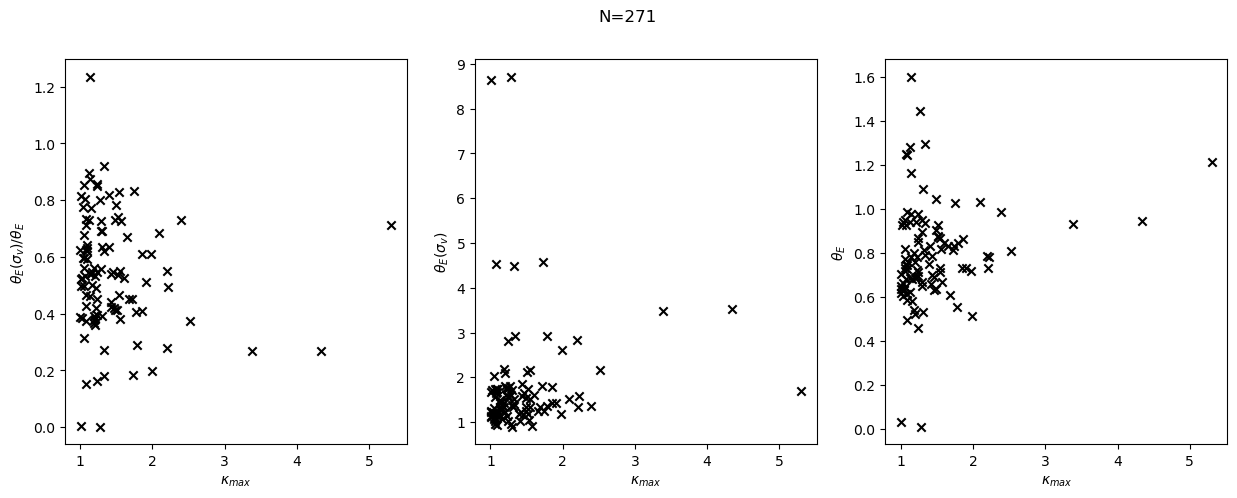

In [301]:
tE_comp_kmax = np.array(theta_E_list)
tE_sis_comp_kmax = np.array(theta_sis_list)
tEsistE_ratio_comp_kmax = tE_comp_kmax/tE_sis_comp_kmax


fig,axis = plt.subplots(1,3,figsize=(15,5))
axis[0].scatter(kmax,tEsistE_ratio_comp_kmax,c="k",marker="x")
axis[0].set_xlabel(r"$\kappa_{max}$")
axis[0].set_ylabel(r"$\theta_E (\sigma_v)/\theta_E$")
axis[1].scatter(kmax,tE_sis_comp_kmax,c="k",marker="x")
axis[1].set_xlabel(r"$\kappa_{max}$")
axis[1].set_ylabel(r"$\theta_E (\sigma_v)$")
axis[2].scatter(kmax,tE_comp_kmax,c="k",marker="x")
axis[2].set_xlabel(r"$\kappa_{max}$")
axis[2].set_ylabel(r"$\theta_E$")
plt.suptitle("N="+str(len(kmax)))
plt.show()

In [29]:
plt.suptitle("N="+str(i_cores.sum()))
plt.scatter(kmax[i_cores],cores_smooth[i_cores],marker="x",c="k")
plt.ylabel("Core (>0)")
plt.xlabel(r"$\kappa_{max}$")


NameError: name 'i_cores' is not defined